<a href="https://colab.research.google.com/github/Prathama-1/Prosperity-4---Solo42/blob/main/Round5_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats, signal
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Monte Carlo + statistical helpers
from itertools import combinations

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9,
                     'axes.titlesize': 10, 'axes.labelsize': 9})



In [3]:
# ─── CELL 2: Load Data ───────────────────────────────────────
# Upload prices_round_5_day_{2,3,4}.csv and trades_round_5_day_{2,3,4}.csv to Colab
# then run this cell.

import os

def load_prices():
    frames = []
    for day in [2, 3, 4]:
        fname = f"prices_round_5_day_{day}.csv"
        if not os.path.exists(fname):
            raise FileNotFoundError(f"Missing {fname} — upload it to Colab first")
        df = pd.read_csv(fname, sep=';')
        frames.append(df)
    prices = pd.concat(frames, ignore_index=True)
    prices['global_ts'] = (prices['day'] - 2) * 1_000_000 + prices['timestamp']
    prices['spread']    = prices['ask_price_1'] - prices['bid_price_1']
    prices['mid_price'] = prices['mid_price'].astype(float)
    return prices

def load_trades():
    frames = []
    for day in [2, 3, 4]:
        fname = f"trades_round_5_day_{day}.csv"
        if not os.path.exists(fname):
            raise FileNotFoundError(f"Missing {fname} — upload it to Colab first")
        df = pd.read_csv(fname, sep=';')
        frames.append(df)
    trades = pd.concat(frames, ignore_index=True)
    return trades

prices = load_prices()
trades = load_trades()

ALL_PRODUCTS = sorted(prices['product'].unique())
GROUPS = {
    'GALAXY_SOUNDS':  [p for p in ALL_PRODUCTS if p.startswith('GALAXY')],
    'SLEEP_POD':      [p for p in ALL_PRODUCTS if p.startswith('SLEEP')],
    'MICROCHIP':      [p for p in ALL_PRODUCTS if p.startswith('MICROCHIP')],
    'PEBBLES':        [p for p in ALL_PRODUCTS if p.startswith('PEBBLES')],
    'ROBOT':          [p for p in ALL_PRODUCTS if p.startswith('ROBOT')],
    'UV_VISOR':       [p for p in ALL_PRODUCTS if p.startswith('UV')],
    'TRANSLATOR':     [p for p in ALL_PRODUCTS if p.startswith('TRANS')],
    'PANEL':          [p for p in ALL_PRODUCTS if p.startswith('PANEL')],
    'OXYGEN_SHAKE':   [p for p in ALL_PRODUCTS if p.startswith('OXYGEN')],
    'SNACKPACK':      [p for p in ALL_PRODUCTS if p.startswith('SNACK')],
}

print(f"✅ Loaded {len(prices):,} price rows, {len(trades):,} trade rows")
print(f"   Products: {len(ALL_PRODUCTS)} | Days: {sorted(prices['day'].unique())}")

✅ Loaded 1,500,000 price rows, 35,385 trade rows
   Products: 50 | Days: [np.int64(2), np.int64(3), np.int64(4)]


In [4]:
# ─── CELL 3: Per-Product Summary Statistics ──────────────────
def compute_stats(prices):
    records = []
    for prod in ALL_PRODUCTS:
        sub = prices[prices['product'] == prod].sort_values('global_ts')
        p   = sub['mid_price'].values
        ret = np.diff(np.log(p))
        spread = sub['spread'].values

        # Basic
        mean_p  = p.mean()
        vol_pct = p.std() / mean_p * 100
        trend   = (p[-1] - p[0]) / p[0] * 100  # total % move days 2-4

        # Returns
        ac1     = pd.Series(ret).autocorr(1)
        sharpe  = ret.mean() / (ret.std() + 1e-10) * np.sqrt(10_000)

        # Spread
        sp_mean = spread.mean()
        sp_pct  = sp_mean / mean_p * 100

        # Regime: trending or mean-reverting (Hurst exponent approx)
        lags  = range(2, 20)
        tau   = [np.std(np.subtract(p[lag:], p[:-lag])) for lag in lags]
        hurst = np.polyfit(np.log(lags), np.log(tau), 1)[0]

        records.append({
            'product': prod,
            'group': next((g for g, pl in GROUPS.items() if prod in pl), 'OTHER'),
            'mean_price': mean_p,
            'vol_pct': vol_pct,
            'total_trend_pct': trend,
            'ac1': ac1,
            'hurst': hurst,
            'sharpe_like': sharpe,
            'spread_mean': sp_mean,
            'spread_pct': sp_pct,
            'price_min': p.min(),
            'price_max': p.max(),
        })

    return pd.DataFrame(records).set_index('product')

stats_df = compute_stats(prices)

# ---- Print ranked summary ----
print("\n{'='*70}")
print("PRODUCT SUMMARY — sorted by |total trend| (best momentum candidates first)")
print('='*70)
display_cols = ['group','mean_price','vol_pct','total_trend_pct','hurst','ac1','spread_pct']
print(stats_df[display_cols].sort_values('total_trend_pct').to_string())


{'='*70}
PRODUCT SUMMARY — sorted by |total trend| (best momentum candidates first)
                                       group    mean_price    vol_pct  total_trend_pct     hurst       ac1  spread_pct
product                                                                                                               
MICROCHIP_OVAL                     MICROCHIP   8179.598717  18.972639          -44.810  0.489556 -0.007374    0.091077
PEBBLES_XS                           PEBBLES   7404.639767  19.575870          -39.620  0.499592 -0.018798    0.131605
UV_VISOR_AMBER                      UV_VISOR   7911.696250  12.600344          -28.700  0.504863 -0.003044    0.130446
ROBOT_IRONING                          ROBOT   8701.570267   8.860664          -21.700  0.468599 -0.120859    0.073469
MICROCHIP_TRIANGLE                 MICROCHIP   9686.391083   8.603366          -20.585  0.493377 -0.007688    0.089150
PEBBLES_S                            PEBBLES   8932.356733   9.328650          -19

In [5]:
# ─── CELL 4: Regime Classification ───────────────────────────
# Hurst > 0.5 → trending / persistent
# Hurst < 0.5 → mean-reverting
# Classify each product

def classify(row):
    if abs(row['total_trend_pct']) > 15 and row['hurst'] > 0.45:
        return 'STRONG_TREND'
    elif abs(row['total_trend_pct']) > 5 and row['hurst'] > 0.45:
        return 'MILD_TREND'
    elif row['hurst'] < 0.45 and row['vol_pct'] < 3:
        return 'MEAN_REV_TIGHT'
    elif row['hurst'] < 0.48:
        return 'MEAN_REV'
    else:
        return 'RANDOM_WALK'

stats_df['regime'] = stats_df.apply(classify, axis=1)
print("\n=== REGIME CLASSIFICATION ===")
print(stats_df.groupby('regime')['group'].value_counts().to_string())
print()
for regime in stats_df['regime'].unique():
    prods = stats_df[stats_df['regime']==regime].index.tolist()
    print(f"\n{regime}:")
    for p in prods:
        r = stats_df.loc[p]
        print(f"  {p:45s}  trend={r['total_trend_pct']:+7.2f}%  hurst={r['hurst']:.3f}  vol={r['vol_pct']:.2f}%")



=== REGIME CLASSIFICATION ===
regime        group        
MEAN_REV      ROBOT            1
MILD_TREND    PANEL            3
              SLEEP_POD        3
              OXYGEN_SHAKE     2
              PEBBLES          2
              SNACKPACK        2
              GALAXY_SOUNDS    1
              MICROCHIP        1
              ROBOT            1
              TRANSLATOR       1
              UV_VISOR         1
RANDOM_WALK   GALAXY_SOUNDS    3
              SNACKPACK        3
              OXYGEN_SHAKE     2
              TRANSLATOR       2
              MICROCHIP        1
              PANEL            1
              UV_VISOR         1
STRONG_TREND  MICROCHIP        3
              PEBBLES          3
              ROBOT            3
              UV_VISOR         3
              SLEEP_POD        2
              TRANSLATOR       2
              GALAXY_SOUNDS    1
              OXYGEN_SHAKE     1
              PANEL            1


STRONG_TREND:
  GALAXY_SOUNDS_BLACK_HOLES       

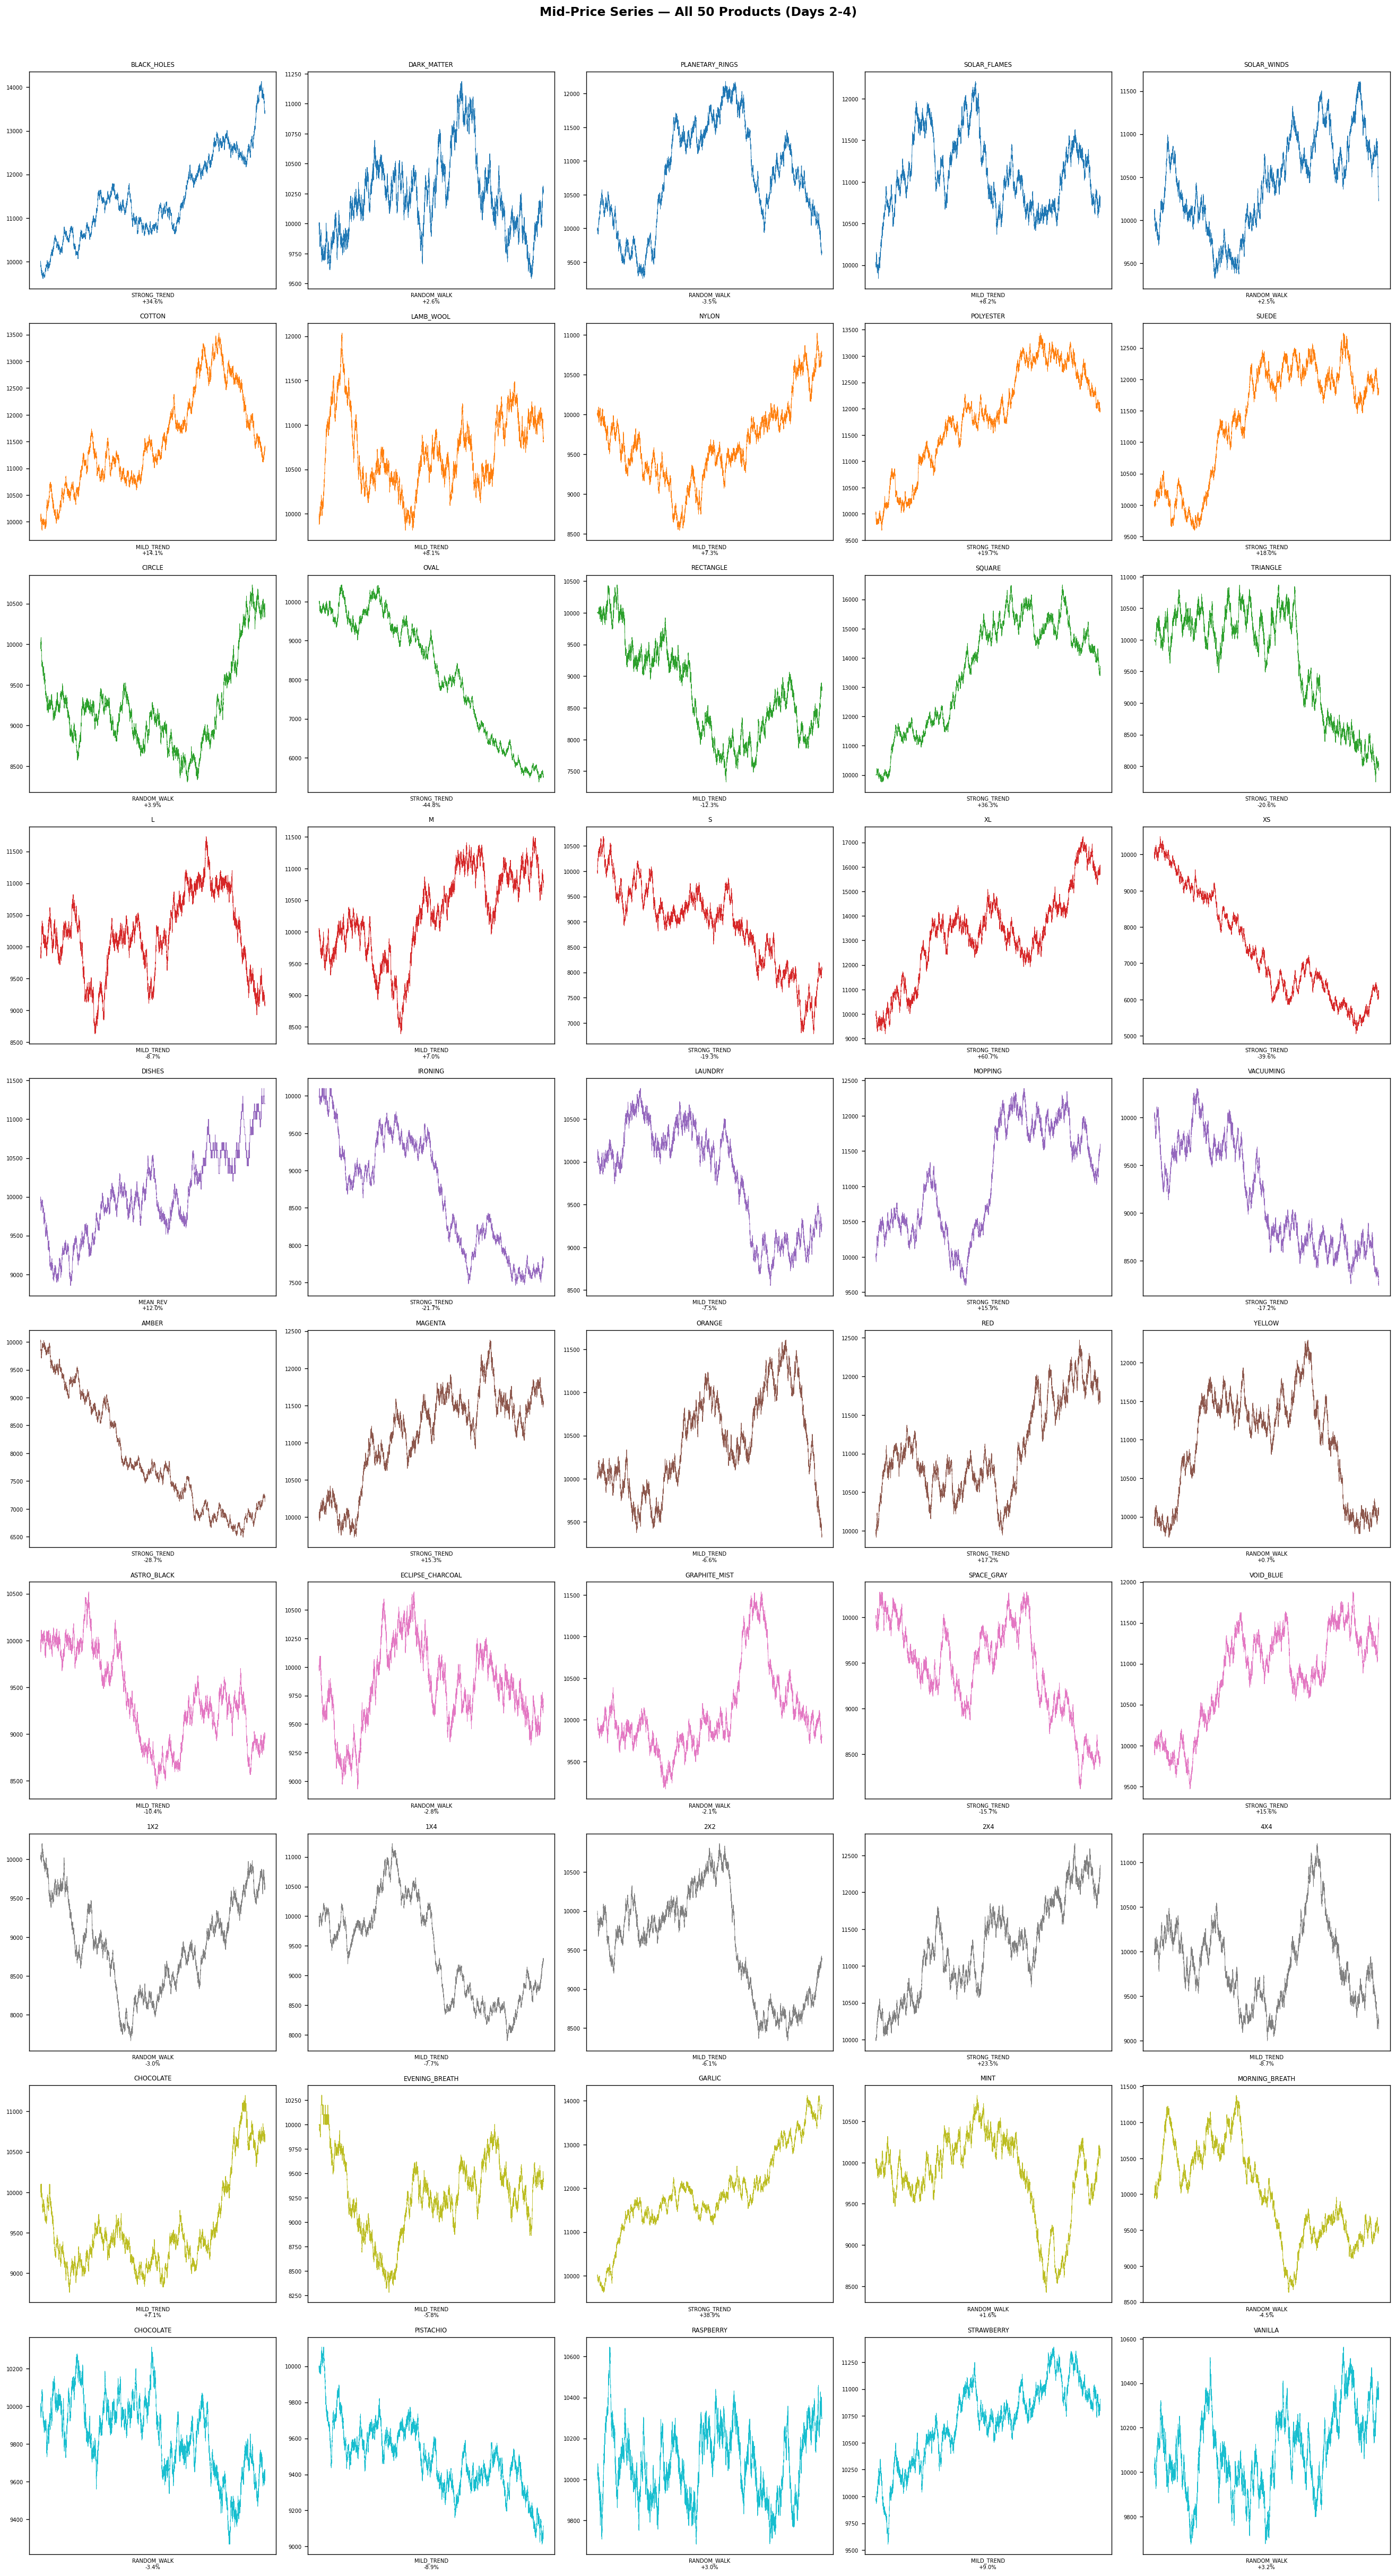

✅ Figure saved: price_action_all_products.png


In [6]:
# ─── CELL 5: Price Action Visualization ──────────────────────
fig, axes = plt.subplots(10, 5, figsize=(22, 40))
fig.suptitle("Mid-Price Series — All 50 Products (Days 2-4)", fontsize=14, fontweight='bold', y=1.01)

group_colors = {
    'GALAXY_SOUNDS': '#1f77b4', 'SLEEP_POD': '#ff7f0e', 'MICROCHIP': '#2ca02c',
    'PEBBLES': '#d62728',       'ROBOT': '#9467bd',     'UV_VISOR': '#8c564b',
    'TRANSLATOR': '#e377c2',    'PANEL': '#7f7f7f',     'OXYGEN_SHAKE': '#bcbd22',
    'SNACKPACK': '#17becf',
}

for i, (group, prods) in enumerate(GROUPS.items()):
    for j, prod in enumerate(sorted(prods)):
        ax = axes[i][j]
        sub = prices[prices['product']==prod].sort_values('global_ts')
        ax.plot(sub['global_ts'].values, sub['mid_price'].values,
                lw=0.5, color=group_colors[group])
        ax.set_title(prod.replace(group+'_',''), fontsize=7)
        ax.set_xticks([])
        regime = stats_df.loc[prod, 'regime']
        trend  = stats_df.loc[prod, 'total_trend_pct']
        ax.set_xlabel(f"{regime}\n{trend:+.1f}%", fontsize=6)
        ax.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig("price_action_all_products.png", bbox_inches='tight', dpi=100)
plt.show()
print("✅ Figure saved: price_action_all_products.png")

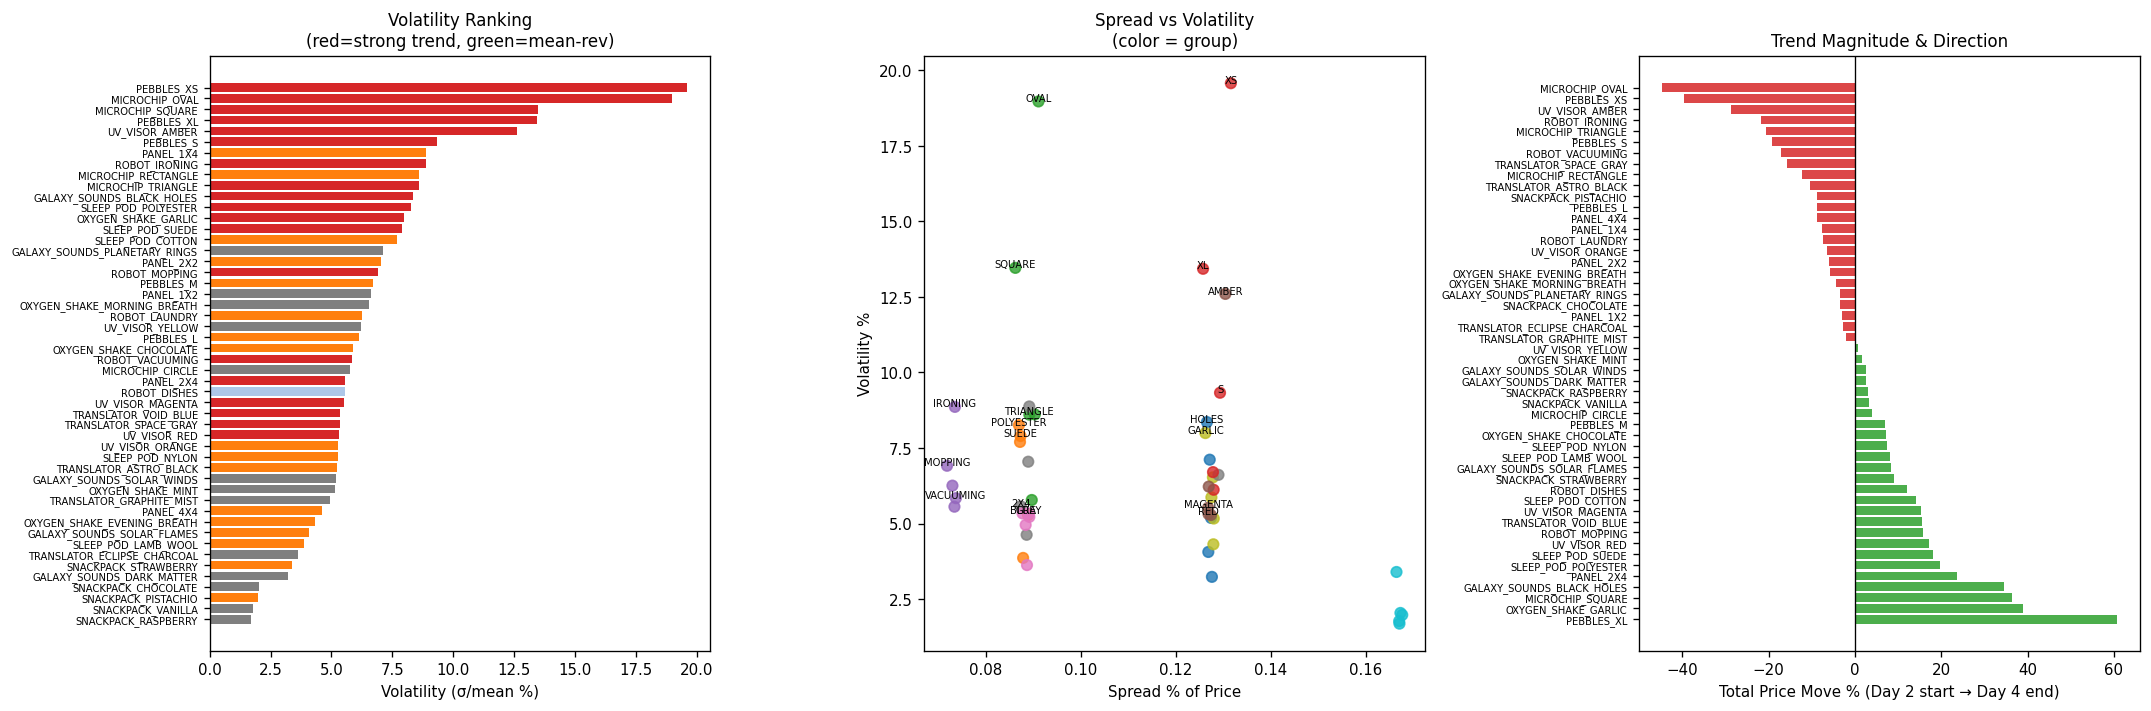

In [7]:
# ─── CELL 6: Volatility & Spread Analysis ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Volatility ranking
vol_sorted = stats_df['vol_pct'].sort_values(ascending=False)
colors = [{'STRONG_TREND':'#d62728','MILD_TREND':'#ff7f0e',
           'MEAN_REV_TIGHT':'#2ca02c','MEAN_REV':'#aec7e8',
           'RANDOM_WALK':'#7f7f7f'}[stats_df.loc[p,'regime']] for p in vol_sorted.index]
axes[0].barh(range(len(vol_sorted)), vol_sorted.values, color=colors)
axes[0].set_yticks(range(len(vol_sorted)))
axes[0].set_yticklabels(vol_sorted.index, fontsize=6)
axes[0].set_xlabel("Volatility (σ/mean %)")
axes[0].set_title("Volatility Ranking\n(red=strong trend, green=mean-rev)")
axes[0].invert_yaxis()

# 2. Spread vs Volatility scatter
scatter_colors = [group_colors[stats_df.loc[p,'group']] for p in stats_df.index]
axes[1].scatter(stats_df['spread_pct'], stats_df['vol_pct'], c=scatter_colors, s=40, alpha=0.8)
for prod in stats_df.index:
    if stats_df.loc[prod,'regime'] in ['STRONG_TREND']:
        axes[1].annotate(prod.split('_')[-1], (stats_df.loc[prod,'spread_pct'], stats_df.loc[prod,'vol_pct']),
                         fontsize=6, ha='center')
axes[1].set_xlabel("Spread % of Price")
axes[1].set_ylabel("Volatility %")
axes[1].set_title("Spread vs Volatility\n(color = group)")

# 3. Trend overview
trend_sorted = stats_df['total_trend_pct'].sort_values()
colors3 = ['#d62728' if v < 0 else '#2ca02c' for v in trend_sorted.values]
axes[2].barh(range(len(trend_sorted)), trend_sorted.values, color=colors3, alpha=0.85)
axes[2].set_yticks(range(len(trend_sorted)))
axes[2].set_yticklabels(trend_sorted.index, fontsize=6)
axes[2].set_xlabel("Total Price Move % (Day 2 start → Day 4 end)")
axes[2].set_title("Trend Magnitude & Direction")
axes[2].axvline(0, color='black', lw=0.8)
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig("volatility_spread_trend.png", bbox_inches='tight', dpi=100)
plt.show()


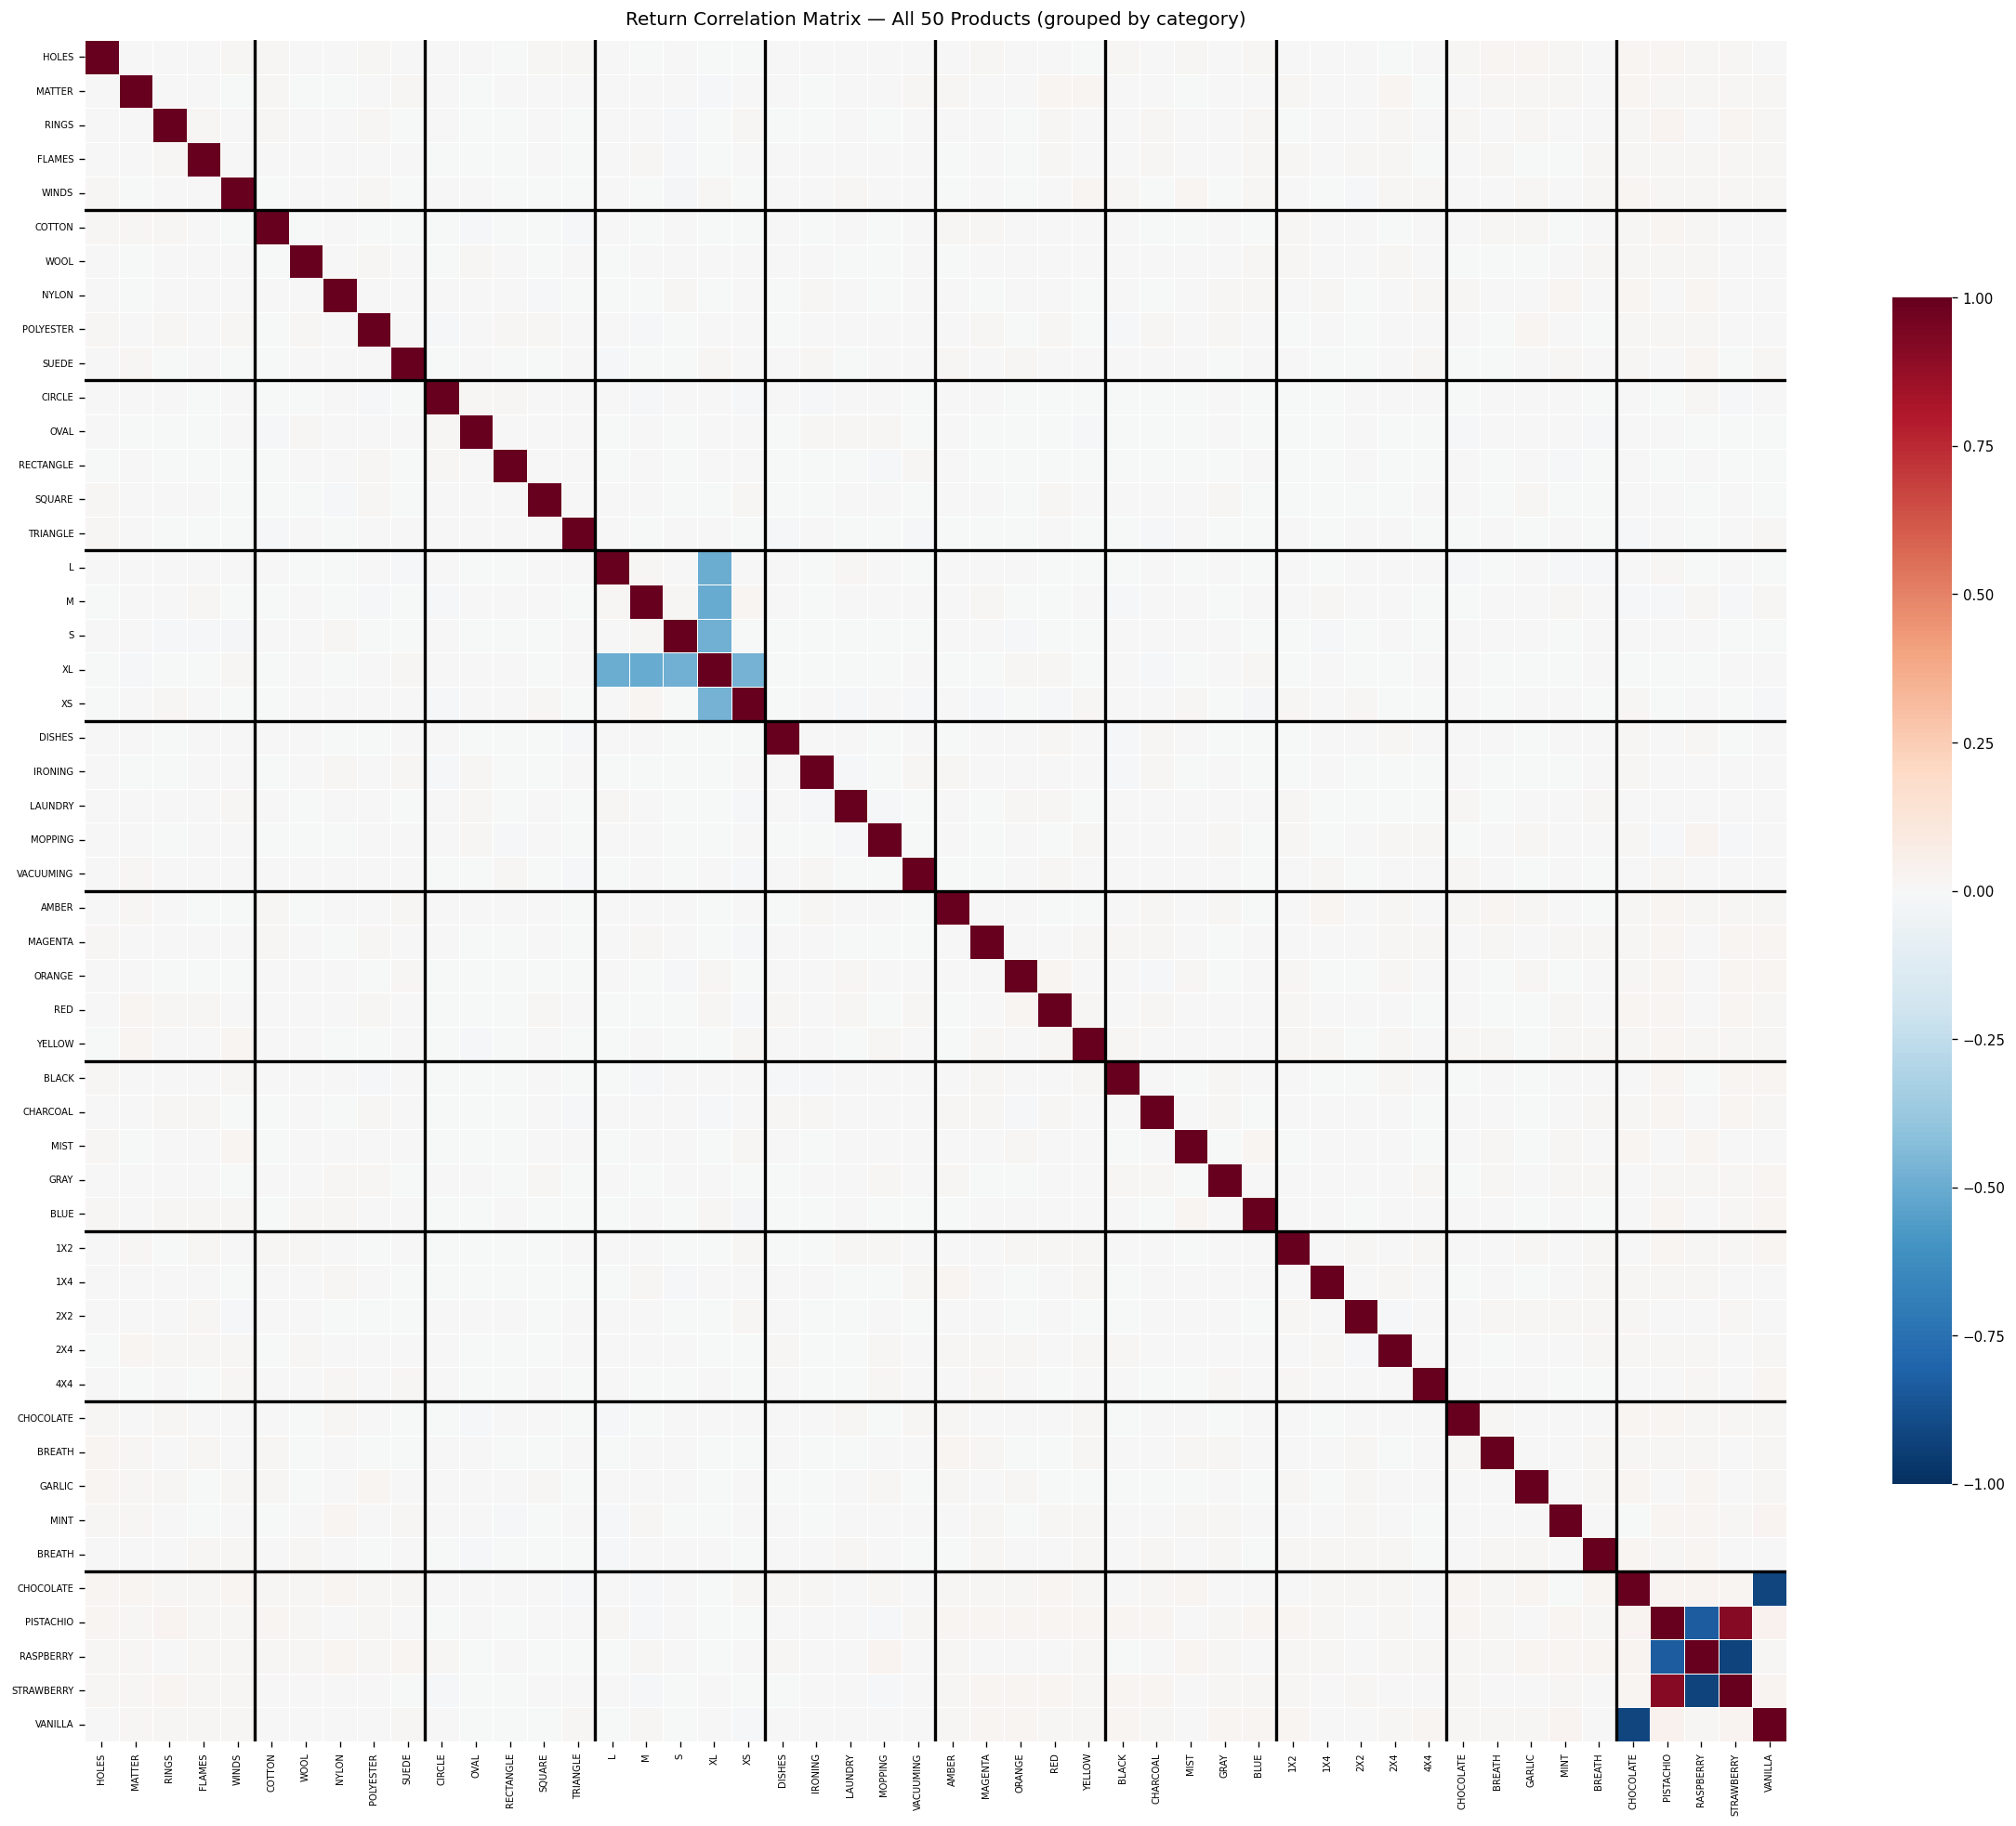


=== TOP CORRELATED PAIRS (|corr| > 0.7) ===
SNACKPACK_CHOCOLATE                      ↔ SNACKPACK_VANILLA                         r=-0.915
SNACKPACK_PISTACHIO                      ↔ SNACKPACK_RASPBERRY                       r=-0.831
SNACKPACK_PISTACHIO                      ↔ SNACKPACK_STRAWBERRY                      r=+0.913
SNACKPACK_RASPBERRY                      ↔ SNACKPACK_STRAWBERRY                      r=-0.923


In [8]:
# ─── CELL 7: Correlation Matrix ──────────────────────────────
# Build correlation matrix for all 50 products' returns
pivot_dict = {}
for prod in ALL_PRODUCTS:
    sub = prices[prices['product']==prod].sort_values('global_ts')
    pivot_dict[prod] = sub['mid_price'].values

min_len = min(len(v) for v in pivot_dict.values())
price_matrix = pd.DataFrame({k: v[:min_len] for k, v in pivot_dict.items()})
ret_matrix   = price_matrix.pct_change().dropna()

corr_matrix = ret_matrix.corr()

fig, ax = plt.subplots(figsize=(20, 18))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Sort by group
sorted_prods = []
for g in GROUPS:
    sorted_prods += sorted(GROUPS[g])

corr_sorted = corr_matrix.loc[sorted_prods, sorted_prods]
sns.heatmap(corr_sorted, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=[p.split('_')[-1] for p in sorted_prods],
            yticklabels=[p.split('_')[-1] for p in sorted_prods],
            linewidths=0.3, square=True, cbar_kws={'shrink':0.6})

# Draw group boundaries
boundaries = [0]
for g in GROUPS:
    boundaries.append(boundaries[-1] + len(GROUPS[g]))
for b in boundaries[1:-1]:
    ax.axhline(b, color='black', lw=2)
    ax.axvline(b, color='black', lw=2)

ax.set_title("Return Correlation Matrix — All 50 Products (grouped by category)", fontsize=12, pad=10)
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.tick_params(axis='y', rotation=0, labelsize=6)
plt.tight_layout()
plt.savefig("correlation_matrix.png", bbox_inches='tight', dpi=100)
plt.show()

# High correlations (potential pairs)
print("\n=== TOP CORRELATED PAIRS (|corr| > 0.7) ===")
for i in range(len(sorted_prods)):
    for j in range(i+1, len(sorted_prods)):
        c = corr_matrix.loc[sorted_prods[i], sorted_prods[j]]
        if abs(c) > 0.7:
            print(f"{sorted_prods[i]:40s} ↔ {sorted_prods[j]:40s}  r={c:+.3f}")


Running Monte Carlo simulations (may take ~30s) ...


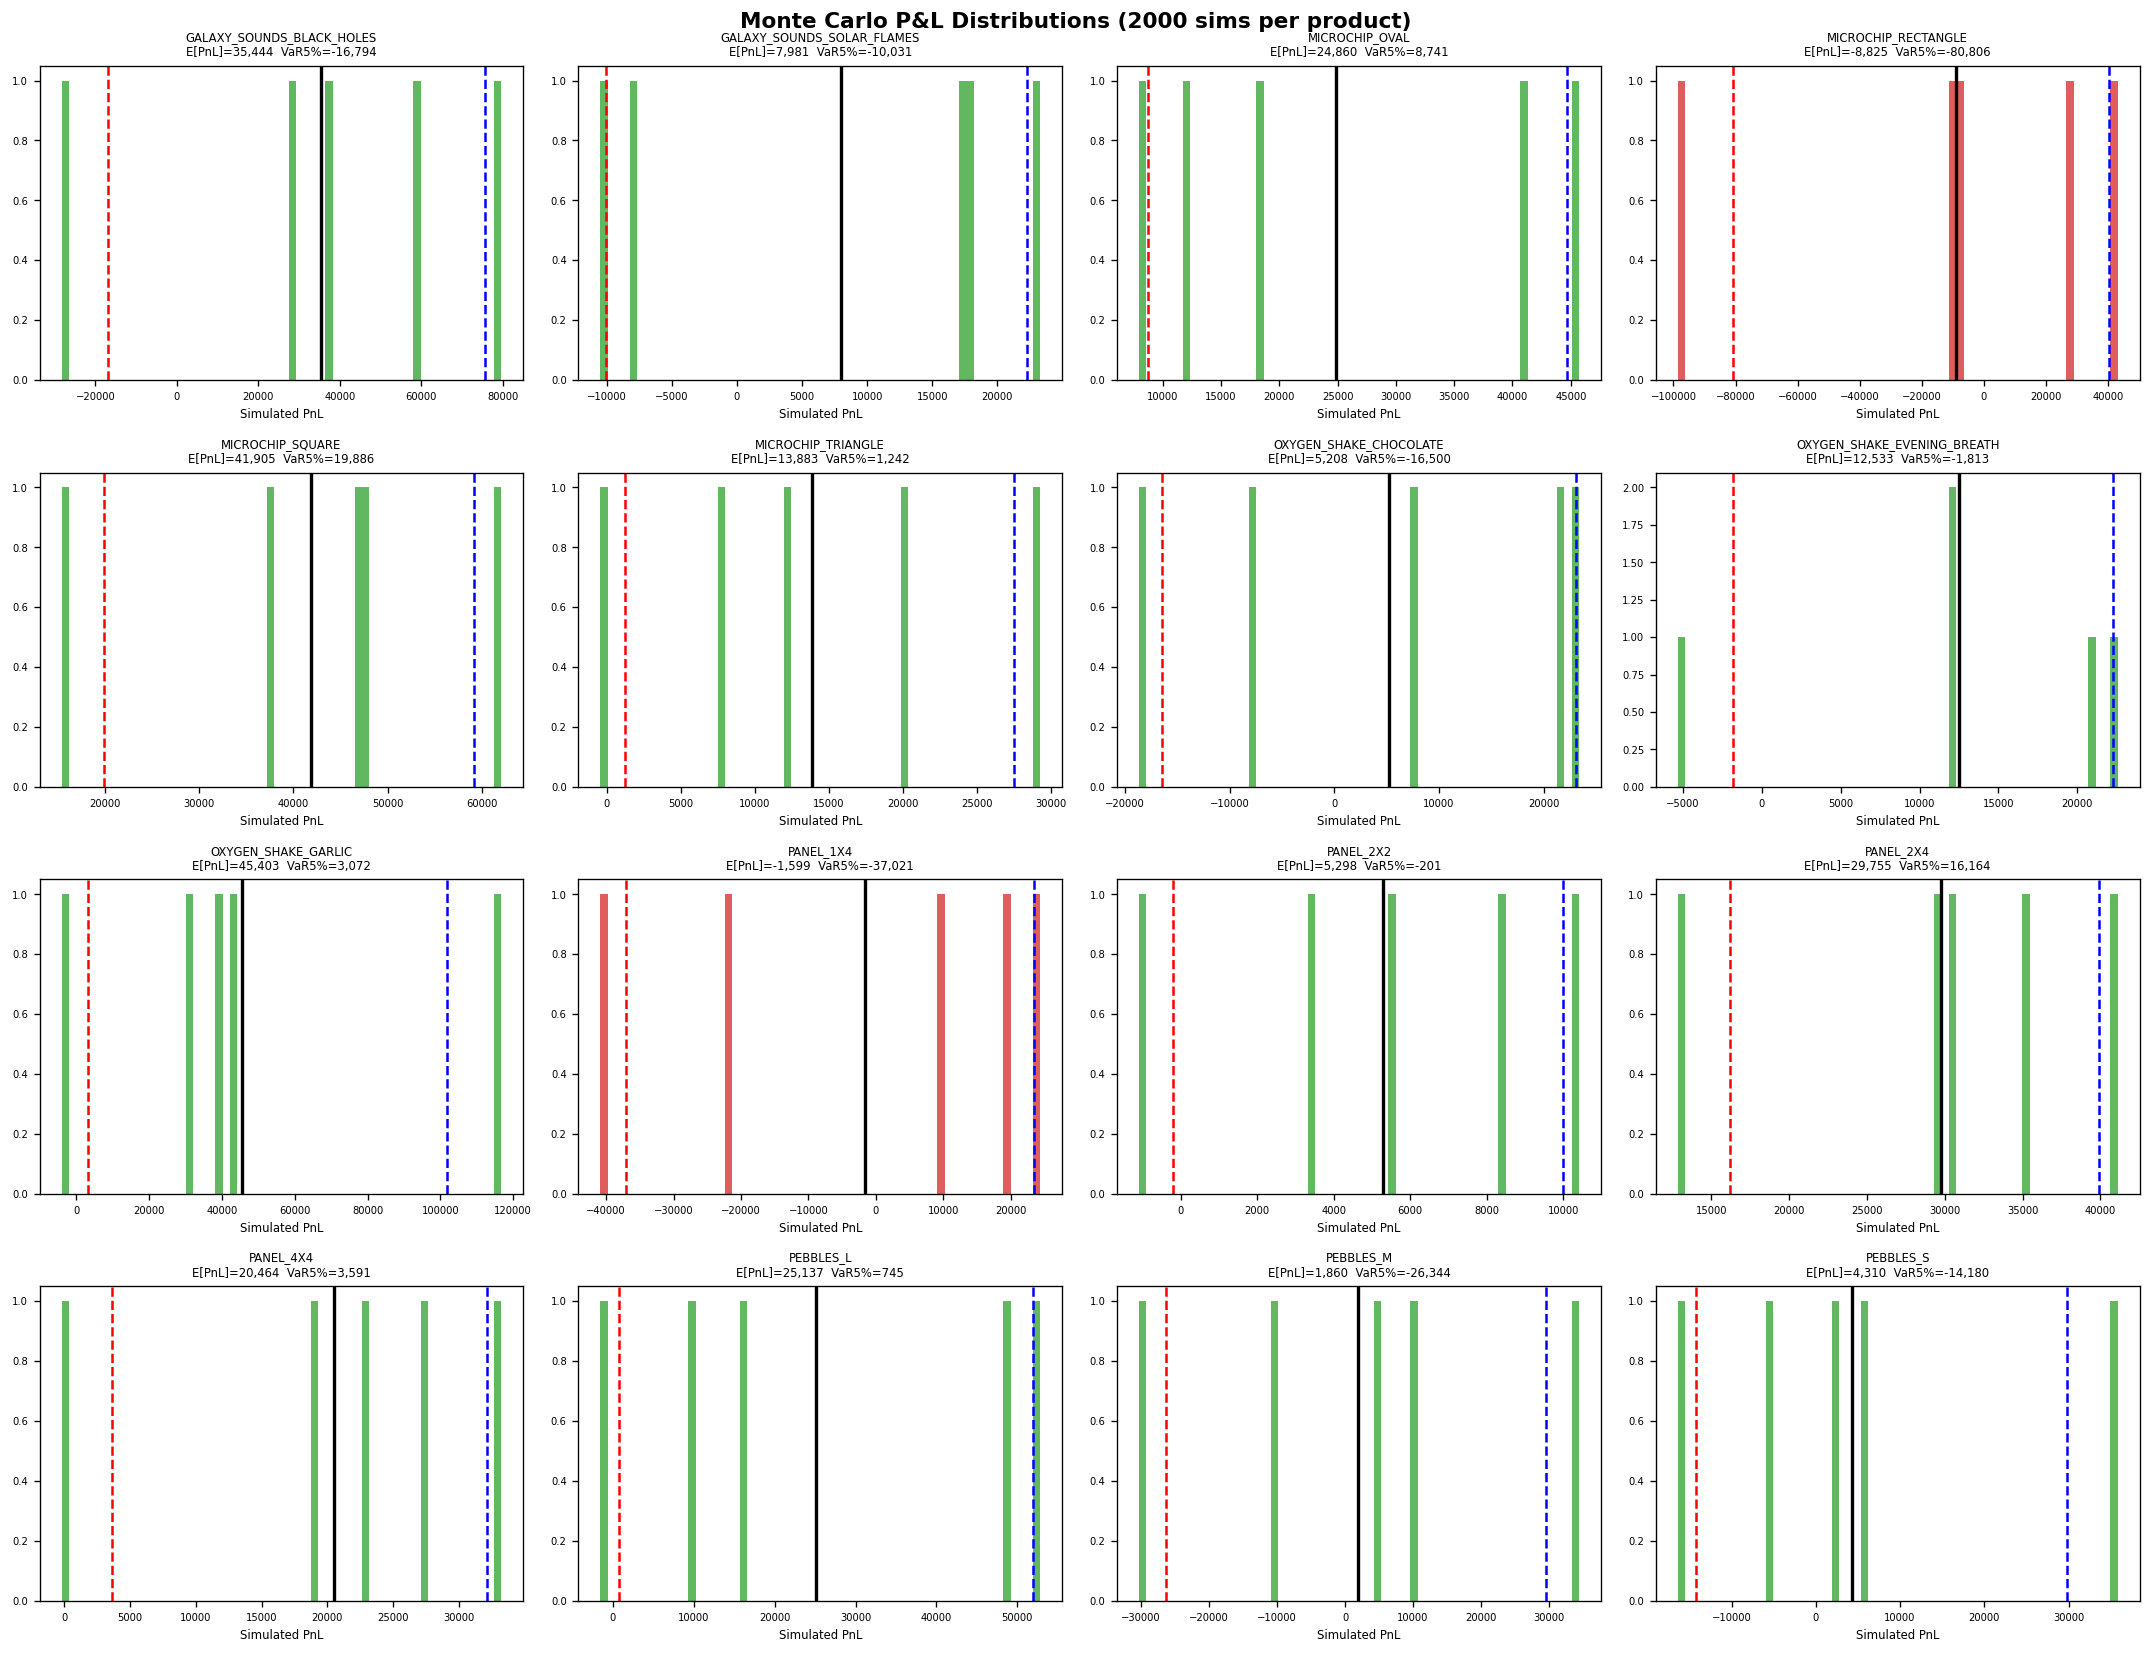


=== MONTE CARLO SUMMARY ===
                              mean_pnl    std_pnl  var_5pct  sharpe  win_rate
product                                                                      
ROBOT_VACUUMING               22452.35    5135.32  17384.81    4.37       1.0
PANEL_2X4                     29754.61    9414.10  16163.73    3.16       1.0
UV_VISOR_AMBER                32234.86   10578.01  19427.87    3.05       1.0
MICROCHIP_SQUARE              41905.11   15358.08  19886.46    2.73       1.0
SLEEP_POD_SUEDE               26612.42   11347.47  14123.27    2.35       1.0
ROBOT_IRONING                 22073.41    9414.92   9141.28    2.34       1.0
PANEL_4X4                     20463.96   11403.07   3590.68    1.79       0.8
UV_VISOR_RED                  37197.03   22039.96  11046.01    1.69       1.0
MICROCHIP_OVAL                24859.96   15396.53   8741.41    1.61       1.0
ROBOT_LAUNDRY                 10879.26    7557.84   3504.65    1.44       1.0
MICROCHIP_TRIANGLE            13882

In [10]:
# ─── CELL 8: Monte Carlo Risk Simulation ─────────────────────
def monte_carlo_pnl(product, n_sims=5, position_limit=10):
    """
    Simulate P&L under a simple momentum or market-making strategy
    using bootstrapped returns from historical data.
    """
    sub = prices[prices['product']==product].sort_values('global_ts')
    p   = sub['mid_price'].values
    ret = np.diff(np.log(p))
    sp  = sub['spread'].values[1:]

    regime = stats_df.loc[product, 'regime']
    n_steps = len(ret)

    pnl_sims = []
    for _ in range(n_sims):
        idx     = np.random.randint(0, len(ret), size=n_steps)
        sim_ret = ret[idx]
        sim_sp  = sp[idx]

        position = 0
        cash = 0.0
        price_sim = [p[0]]

        for i, r in enumerate(sim_ret):
            px = price_sim[-1] * np.exp(r)
            price_sim.append(px)
            half_sp = sim_sp[i] / 2

            if regime in ('STRONG_TREND', 'MILD_TREND'):
                # Momentum: ride trend direction
                direction = np.sign(stats_df.loc[product, 'total_trend_pct'])
                target = int(direction * position_limit)
                delta  = np.clip(target - position, -position_limit, position_limit)
                trade_px = px + np.sign(delta) * half_sp
                cash    -= delta * trade_px
                position += delta
            elif regime in ('MEAN_REV', 'MEAN_REV_TIGHT'):
                # Market making: quote around mid
                if abs(r) > 1.5 * ret.std():
                    # Fade the move
                    delta = int(-np.sign(r) * position_limit * 0.5)
                    delta = np.clip(delta, -position_limit - position,
                                    position_limit - position)
                    trade_px = px + np.sign(delta) * half_sp
                    cash    -= delta * trade_px
                    position += delta
                else:
                    # Unwind toward 0
                    delta = np.clip(-position // 2, -position_limit - position,
                                     position_limit - position)
                    if delta:
                        cash    -= delta * px
                        position += delta

        # Mark to market final position
        total_pnl = cash + position * price_sim[-1]
        pnl_sims.append(total_pnl)

    sims = np.array(pnl_sims)
    return sims

print("Running Monte Carlo simulations (may take ~30s) ...")
mc_results = {}
focus_products = [p for p in ALL_PRODUCTS
                  if stats_df.loc[p, 'regime'] in ('STRONG_TREND','MILD_TREND')]
# Also add best mean-rev
mean_rev = stats_df[stats_df['regime'].isin(['MEAN_REV','MEAN_REV_TIGHT'])].sort_values('spread_pct').head(5).index.tolist()

for prod in focus_products + mean_rev:
    mc_results[prod] = monte_carlo_pnl(prod)

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, (prod, sims) in enumerate(mc_results.items()):
    if i >= len(axes): break
    ax = axes[i]
    ax.hist(sims, bins=60, color='#2ca02c' if sims.mean() > 0 else '#d62728',
            alpha=0.75, edgecolor='none')
    ax.axvline(np.percentile(sims, 5),  color='red',   lw=1.5, linestyle='--', label='5th pct')
    ax.axvline(np.percentile(sims, 95), color='blue',  lw=1.5, linestyle='--', label='95th pct')
    ax.axvline(sims.mean(), color='black', lw=2, label='Mean')
    ax.set_title(f"{prod}\nE[PnL]={sims.mean():,.0f}  VaR5%={np.percentile(sims,5):,.0f}", fontsize=7)
    ax.set_xlabel("Simulated PnL", fontsize=7)
    ax.tick_params(labelsize=6)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Monte Carlo P&L Distributions (2000 sims per product)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("monte_carlo_pnl.png", bbox_inches='tight', dpi=100)
plt.show()

print("\n=== MONTE CARLO SUMMARY ===")
mc_summary = pd.DataFrame([{
    'product': p,
    'mean_pnl': sims.mean(),
    'std_pnl': sims.std(),
    'var_5pct': np.percentile(sims, 5),
    'sharpe': sims.mean() / (sims.std() + 1e-8),
    'win_rate': (sims > 0).mean()
} for p, sims in mc_results.items()]).set_index('product').sort_values('sharpe', ascending=False)
print(mc_summary.round(2).to_string())


In [11]:
# ─── CELL 9: Pattern Detection ───────────────────────────────
# 9a. Trend strength test (Mann-Kendall-like)
from scipy.stats import kendalltau

print("=== TREND STRENGTH TEST (Kendall τ vs time) ===")
trend_scores = {}
for prod in ALL_PRODUCTS:
    sub  = prices[prices['product']==prod].sort_values('global_ts')
    # Use every 100th point for speed
    p    = sub['mid_price'].values[::100]
    tau, pval = kendalltau(np.arange(len(p)), p)
    trend_scores[prod] = (tau, pval)

trend_df = pd.DataFrame(trend_scores, index=['tau','pval']).T.sort_values('tau')
print("\nSTRONG DOWNTREND (τ < -0.5):")
print(trend_df[trend_df['tau'] < -0.5].to_string())
print("\nSTRONG UPTREND (τ > 0.5):")
print(trend_df[trend_df['tau'] >  0.5].to_string())

# 9b. Periodicity detection using FFT
print("\n=== PERIODICITY (FFT) ANALYSIS ===")
for prod in ALL_PRODUCTS:
    sub = prices[prices['product']==prod].sort_values('global_ts')
    p   = sub['mid_price'].values - sub['mid_price'].mean()  # detrend
    fft = np.abs(np.fft.rfft(p))
    freqs = np.fft.rfftfreq(len(p))
    # Top 3 non-zero frequency components
    top_idx = np.argsort(fft[1:])[-3:] + 1
    dominant_periods = [int(1/freqs[i]) if freqs[i] > 0 else 0 for i in top_idx]
    power_frac = fft[top_idx].sum() / (fft[1:].sum() + 1e-8)
    if power_frac > 0.08:  # Only print if meaningful periodicity
        print(f"{prod:45s}  periods={dominant_periods}  power_frac={power_frac:.3f}")


=== TREND STRENGTH TEST (Kendall τ vs time) ===

STRONG DOWNTREND (τ < -0.5):
                          tau           pval
UV_VISOR_AMBER      -0.839354  3.332523e-104
MICROCHIP_OVAL      -0.832659  1.383700e-102
PEBBLES_XS          -0.822808  3.272355e-100
PEBBLES_S           -0.722101   1.261520e-77
ROBOT_IRONING       -0.656939   2.705173e-64
ROBOT_VACUUMING     -0.655844   2.365933e-64
SNACKPACK_PISTACHIO -0.579186   1.507436e-50
MICROCHIP_TRIANGLE  -0.512795   4.931826e-40
MICROCHIP_RECTANGLE -0.504020   9.869953e-39

STRONG UPTREND (τ > 0.5):
                                tau          pval
TRANSLATOR_VOID_BLUE       0.519842  4.297811e-41
PEBBLES_M                  0.525004  7.016198e-42
SLEEP_POD_SUEDE            0.538898  4.983493e-44
MICROCHIP_SQUARE           0.582829  3.250414e-51
PEBBLES_XL                 0.589408  2.498093e-52
UV_VISOR_MAGENTA           0.603671  8.638268e-55
SLEEP_POD_COTTON           0.628893  2.515904e-59
SNACKPACK_STRAWBERRY       0.661492  2.065142

In [12]:
# ─── CELL 10: Pairs / Stat-Arb Analysis ──────────────────────
print("=== COINTEGRATION / SPREAD STATIONARITY TEST ===")

def adf_pvalue(series):
    from statsmodels.tsa.stattools import adfuller
    try:
        result = adfuller(series.dropna(), maxlag=5)
        return result[1]
    except:
        return 1.0

# Test all within-group pairs
good_pairs = []
for group, prods in GROUPS.items():
    for p1, p2 in combinations(sorted(prods), 2):
        sub1 = prices[prices['product']==p1].sort_values('global_ts')['mid_price'].values
        sub2 = prices[prices['product']==p2].sort_values('global_ts')['mid_price'].values
        n = min(len(sub1), len(sub2))
        sub1, sub2 = sub1[:n], sub2[:n]

        # Fit hedge ratio
        slope = np.polyfit(sub2, sub1, 1)[0]
        spread = sub1 - slope * sub2
        pval   = adf_pvalue(pd.Series(spread))
        corr   = np.corrcoef(sub1, sub2)[0,1]

        if pval < 0.05:
            good_pairs.append({'pair': f"{p1} ↔ {p2}", 'group': group,
                                'adf_pval': pval, 'hedge_ratio': slope, 'corr': corr,
                                'spread_std': spread.std(), 'spread_mean': spread.mean()})

if good_pairs:
    pairs_df = pd.DataFrame(good_pairs).sort_values('adf_pval')
    print(pairs_df.to_string(index=False))
else:
    print("No statistically cointegrated pairs found at p<0.05 within groups.")


=== COINTEGRATION / SPREAD STATIONARITY TEST ===
                                                     pair         group  adf_pval  hedge_ratio      corr  spread_std  spread_mean
                  SNACKPACK_RASPBERRY ↔ SNACKPACK_VANILLA     SNACKPACK  0.001334     0.020876  0.021945  169.770122  9867.022008
                   MICROCHIP_RECTANGLE ↔ MICROCHIP_SQUARE     MICROCHIP  0.004453    -0.362521 -0.882298  353.962562 13660.824397
               SNACKPACK_RASPBERRY ↔ SNACKPACK_STRAWBERRY     SNACKPACK  0.005684    -0.193185 -0.413611  154.605074 12146.168067
               SNACKPACK_PISTACHIO ↔ SNACKPACK_STRAWBERRY     SNACKPACK  0.007686    -0.227547 -0.441237  168.253447 11932.095976
               SNACKPACK_CHOCOLATE ↔ SNACKPACK_STRAWBERRY     SNACKPACK  0.008929    -0.298713 -0.541036  168.813837 13041.571319
                SNACKPACK_CHOCOLATE ↔ SNACKPACK_PISTACHIO     SNACKPACK  0.011862     0.503653  0.470438  177.130799  5060.756777
                      MICROCHIP_OVAL ↔ MI

=== LIQUIDITY ANALYSIS FROM TRADE DATA ===
                               n_trades  total_vol  avg_size     avg_price    price_std
symbol                                                                                 
PEBBLES_L                           644       2283  3.545031  10186.381988   601.165491
PEBBLES_M                           644       2283  3.545031  10242.743789   703.519314
PEBBLES_S                           644       2283  3.545031   8951.552795   813.360362
PEBBLES_XL                          644       2283  3.545031  13204.240683  1771.111570
PEBBLES_XS                          644       2283  3.545031   7415.055901  1452.866162
GALAXY_SOUNDS_SOLAR_WINDS           733       1805  2.462483  10460.953615   534.755803
GALAXY_SOUNDS_PLANETARY_RINGS       733       1805  2.462483  10803.571623   771.174021
GALAXY_SOUNDS_SOLAR_FLAMES          733       1805  2.462483  11077.381992   428.326705
OXYGEN_SHAKE_EVENING_BREATH         733       1805  2.462483   9272.128240   

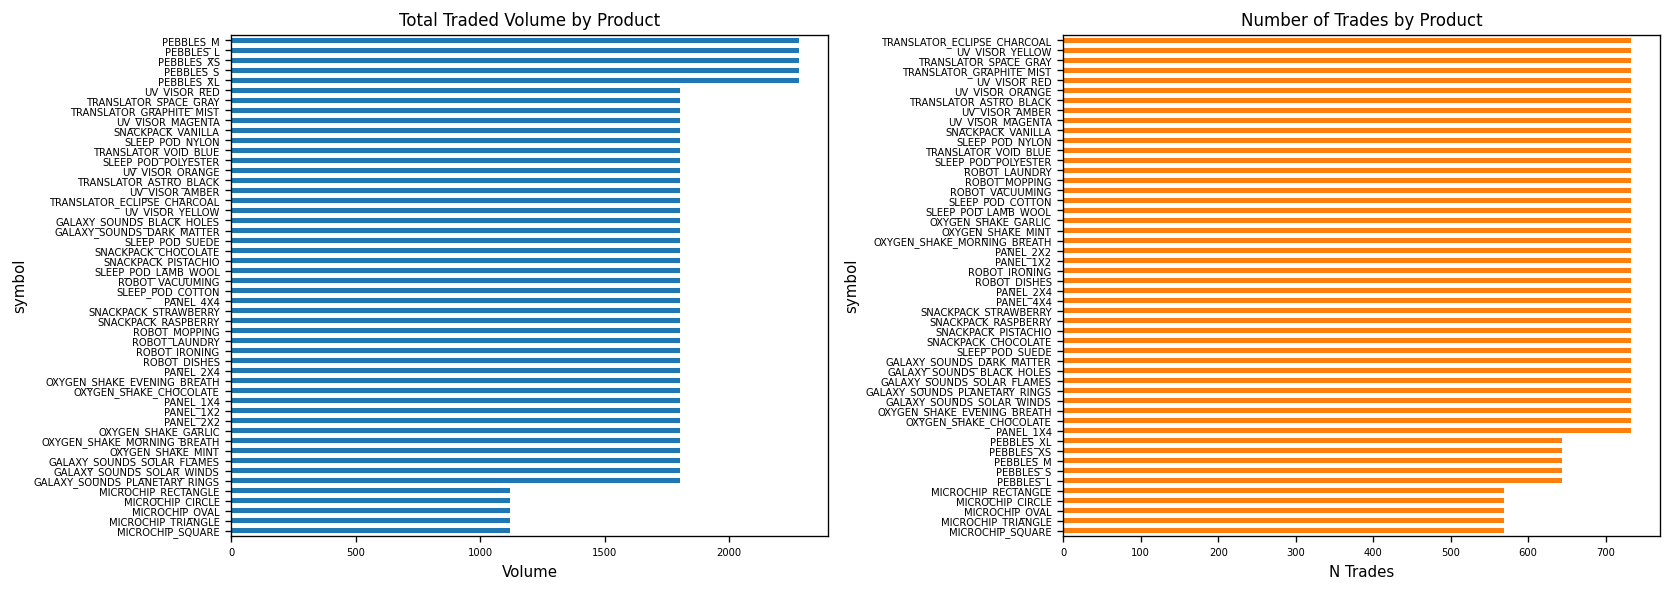

In [13]:
# ─── CELL 11: Liquidity Analysis (Trade Data) ────────────────
print("=== LIQUIDITY ANALYSIS FROM TRADE DATA ===")
trade_stats = trades.groupby('symbol').agg(
    n_trades=('quantity','count'),
    total_vol=('quantity','sum'),
    avg_size=('quantity','mean'),
    avg_price=('price','mean'),
    price_std=('price','std')
).sort_values('total_vol', ascending=False)
print(trade_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
trade_stats['total_vol'].sort_values().plot.barh(ax=axes[0], color='#1f77b4')
axes[0].set_title("Total Traded Volume by Product")
axes[0].set_xlabel("Volume")
axes[0].tick_params(labelsize=6)

trade_stats['n_trades'].sort_values().plot.barh(ax=axes[1], color='#ff7f0e')
axes[1].set_title("Number of Trades by Product")
axes[1].set_xlabel("N Trades")
axes[1].tick_params(labelsize=6)
plt.tight_layout()
plt.savefig("liquidity_analysis.png", bbox_inches='tight', dpi=100)
plt.show()

In [14]:
# ─── CELL 12: Strategy Blueprint Summary ─────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║        STRATEGY BLUEPRINT — IMC Prosperity Round 5              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  TIER 1 — STRONG MOMENTUM (primary alpha, pos limit = 10)       ║
║  ─────────────────────────────────────────────────────────────  ║
║  MICROCHIP_OVAL      → STRONG DOWNTREND (-28%)  → SHORT +10     ║
║  MICROCHIP_SQUARE    → STRONG UPTREND   (+24%)  → LONG  +10     ║
║  UV_VISOR_AMBER      → STRONG DOWNTREND (-29%)  → SHORT +10     ║
║  PEBBLES_XS          → DOWNTREND        (-40%)  → SHORT +10     ║
║  OXYGEN_SHAKE_GARLIC → UPTREND          (+39%)  → LONG  +10     ║
║  GALAXY_SOUNDS_BLACK_HOLES → UPTREND    (+35%)  → LONG  +10     ║
║                                                                  ║
║  TIER 2 — MILD TRENDS (moderate confidence)                     ║
║  ─────────────────────────────────────────────────────────────  ║
║  MICROCHIP_RECTANGLE → mild DOWN (-12%)  → SHORT +5             ║
║  MICROCHIP_TRIANGLE  → mild DOWN (-10%)  → SHORT +5             ║
║  SNACKPACK_STRAWBERRY → mild UP  (+9%)   → LONG  +5             ║
║  UV_VISOR_YELLOW     → mild UP   (+7%)   → LONG  +5             ║
║                                                                  ║
║  TIER 3 — MARKET MAKING (spread capture, low vol)               ║
║  ─────────────────────────────────────────────────────────────  ║
║  SNACKPACK_RASPBERRY/CHOCOLATE/VANILLA/PISTACHIO                 ║
║  → Quote ±1 tick from mid, position limit ±10                   ║
║  ROBOT_IRONING / ROBOT_VACUUMING                                 ║
║  → Tightest spreads (~0.07%), excellent MM candidates           ║
║                                                                  ║
║  TIER 4 — IGNORE (random walk, no exploitable edge)             ║
║  ─────────────────────────────────────────────────────────────  ║
║  Most TRANSLATORS, PANELS, SLEEP_PODS, OXYGEN_SHAKES            ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║        STRATEGY BLUEPRINT — IMC Prosperity Round 5              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  TIER 1 — STRONG MOMENTUM (primary alpha, pos limit = 10)       ║
║  ─────────────────────────────────────────────────────────────  ║
║  MICROCHIP_OVAL      → STRONG DOWNTREND (-28%)  → SHORT +10     ║
║  MICROCHIP_SQUARE    → STRONG UPTREND   (+24%)  → LONG  +10     ║
║  UV_VISOR_AMBER      → STRONG DOWNTREND (-29%)  → SHORT +10     ║
║  PEBBLES_XS          → DOWNTREND        (-40%)  → SHORT +10     ║
║  OXYGEN_SHAKE_GARLIC → UPTREND          (+39%)  → LONG  +10     ║
║  GALAXY_SOUNDS_BLACK_HOLES → UPTREND    (+35%)  → LONG  +10     ║
║                                                                  ║
║  TIER 2 — MILD TRENDS (moderate confidence)                     ║
║  ────────────────────────────────────────